## What are the most demanded skills for the top 3 most popular data roles?

#### Methodology

1. Clean-up skill column
2. Calculate skill count based on `job_title_short`
3. Calculate skill percentage
4. Plot final findings

### Import Libraries and Data

In [6]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter Data for France

Filter the data for the market of France which is more meaningful for me

In [2]:
df_FR = df[df['job_country'] == 'France']

### Explode Skills

Each job can include multiple skills in a single field, which makes analysis difficult.  
To better understand skill demand, I transform the dataset so that each skill appears as a separate row, allowing for more accurate aggregation and comparison across roles.

In [3]:
df_skills = df_FR.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
12,Stagiaire Data Analyst (H/F) - Lyon (69006),sql
12,Stagiaire Data Analyst (H/F) - Lyon (69006),php
12,Stagiaire Data Analyst (H/F) - Lyon (69006),excel
12,Stagiaire Data Analyst (H/F) - Lyon (69006),power bi
12,Stagiaire Data Analyst (H/F) - Lyon (69006),sap
...,...,...
785693,Senior Data Scientist BI,pandas
785693,Senior Data Scientist BI,numpy
785693,Senior Data Scientist BI,keras
785693,Senior Data Scientist BI,pytorch


### Count Skills per Job Title
To identify the most in-demand skills for each role, I count how often each skill appears within each job title.  
This allows me to highlight the key skills associated with each position and better understand role-specific requirements.

In [ ]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
944,python,Data Scientist,6320
1211,sql,Data Analyst,6213
943,python,Data Engineer,6188
1212,sql,Data Engineer,5319
942,python,Data Analyst,4506
...,...,...,...
289,drupal,Cloud Engineer,1
1163,solidity,Senior Data Engineer,1
1162,solidity,Data Scientist,1
309,electron,Business Analyst,1


### Select Top 3 Data Roles

To focus the analysis on the most relevant positions, I select the three most common data roles: Data Analyst, Data Engineer, and Data Scientist.  
This ensures a meaningful comparison of skill requirements across the most in-demand roles in the data job market.

In [5]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

### Compare Top Skills Across Roles

I visualize the top 5 most requested skills for each of the three main data roles to make comparisons more intuitive.  
This helps reveal which skills are shared across roles and which are more role-specific.

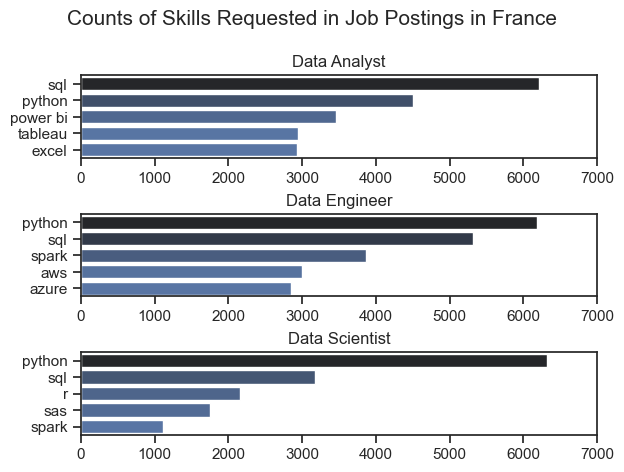

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 7000) # making the scales the same

fig.suptitle('Counts of Skills Requested in Job Postings in France', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()

### Convert Counts to Percentages

Counts alone don’t reflect how dominant a skill is across job postings.  
To make comparisons more meaningful, I convert counts into percentages relative to the total number of jobs per role.

In [ ]:
df_job_title_count = df_FR['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Analyst,13803
1,Data Engineer,10936
2,Data Scientist,9497
3,Software Engineer,1203
4,Senior Data Engineer,1186
5,Senior Data Scientist,1029
6,Senior Data Analyst,804
7,Business Analyst,738
8,Machine Learning Engineer,388
9,Cloud Engineer,338


Then I calculate the percentage of job postings that require each skill within each role to enable fair comparisons.  
This highlights how important each skill is relative to the total demand for that role.

In [13]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,6320,9497,66.547331
1,sql,Data Analyst,6213,13803,45.011954
2,python,Data Engineer,6188,10936,56.583760
3,sql,Data Engineer,5319,10936,48.637527
4,python,Data Analyst,4506,13803,32.645077
...,...,...,...,...,...
1469,drupal,Cloud Engineer,1,338,0.295858
1470,solidity,Senior Data Engineer,1,1186,0.084317
1471,solidity,Data Scientist,1,9497,0.010530
1472,electron,Business Analyst,1,738,0.135501


### Visualize Skill Demand by Percentage

To better compare roles of different sizes, I visualize the top 5 skills by percentage for each of the three main data roles.  
This makes it easier to see which skills are most consistently requested within each role, beyond raw volume alone.

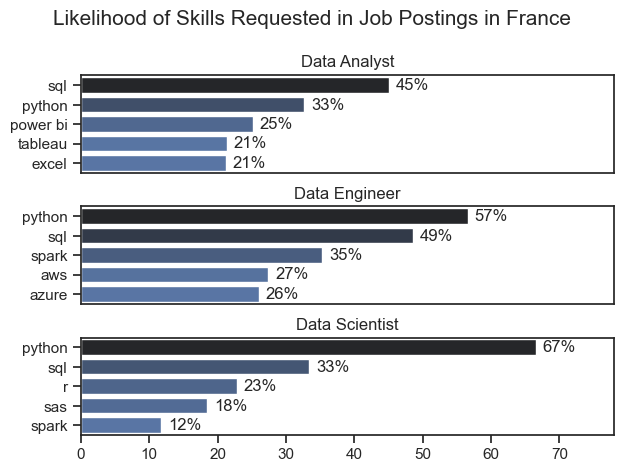

In [ ]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    # removing the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # labeling the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in Job Postings in France', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()